<a href="https://colab.research.google.com/github/Prdazk/Repository-Tugas-Akhir/blob/main/Model_Yolov8n_pt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================
# 1️Mount Google Drive
# ==============================================
from google.colab import drive
drive.mount('/content/drive')

# ==============================================
# Set path folder dataset
# ==============================================
dataset_path = "/content/drive/MyDrive/Dataset Training/Dataset 4 Objek.zip"

# ==============================================
# Cek apakah folder ada
# ==============================================
import os

if os.path.exists(dataset_path):
    print("✅ Folder dataset terhubung:", dataset_path)
else:
    print("❌ Folder dataset TIDAK DITEMUKAN:", dataset_path)

Mounted at /content/drive
✅ Folder dataset terhubung: /content/drive/MyDrive/Dataset Training/Dataset 4 Objek.zip


In [ ]:
# ==============================================
# Extract dataset zip
# ==============================================
import zipfile

extract_path = "/content/dataset"

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset berhasil diekstrak ke:", extract_path)

✅ Dataset berhasil diekstrak ke: /content/dataset


In [ ]:
# ==============================================
# 5️⃣ Cek isi folder dataset
# ==============================================
import os

dataset_folder = "/content/dataset"

for root, dirs, files in os.walk(dataset_folder):
    level = root.replace(dataset_folder, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

dataset/
    README.dataset.txt
    data.yaml
    README.roboflow.txt
    valid/
        labels/
            000000035282_jpg.rf.68154f8a24f806d5cc48c6744aa7c7f4.txt
            000000157026_jpg.rf.8acdda968e905ce8493c3e455bbb3308.txt
            000000334320_jpg.rf.979c5253f3d4a012795a987042941b06.txt
            000000247818_jpg.rf.21c75ab311bf28193342d8dc3943ba97.txt
            000000127499_jpg.rf.5f7a449aedaabfcb5cba4038b9ccb2ae.txt
        images/
            000000427343_jpg.rf.a2307ae2b86fbf9da6d6e40308e85978.jpg
            000000137442_jpg.rf.a6a7ccbe4c72475f643e69d8525bd165.jpg
            000000091005_jpg.rf.52a7423957fc928ee538a5b68a2f65f6.jpg
            000000448703_jpg.rf.1d543d97fd7273e09b0673f2dd28a576.jpg
            000000374360_jpg.rf.010ac7bd6d157e2519f850ff445ae727.jpg
    test/
        labels/
            000000413339_jpg.rf.bbfc46266b4cc60c2e3b1af29b2f3aff.txt
            000000156175_jpg.rf.9614ef02751d72c771bc9ba2a9ac4fc4.txt
            000000553561_jpg.rf.1

In [ ]:
# ==============================================
# Cek distribusi jumlah objek tiap class
# ==============================================
import os
from collections import Counter

labels_path = "/content/dataset"

class_counter = Counter()

for split in ["train", "valid", "test"]:
    label_dir = os.path.join(labels_path, split, "labels")

    for file in os.listdir(label_dir):
        if file.endswith(".txt"):
            with open(os.path.join(label_dir, file), "r") as f:
                for line in f.readlines():
                    class_id = int(line.split()[0])
                    class_counter[class_id] += 1

# Mapping class
classes = {
    0: "motor",
    1: "mobil",
    2: "bus",
    3: "truk"
}

print("Distribusi jumlah objek:\n")

for class_id, count in sorted(class_counter.items()):
    print(f"{classes[class_id]} : {count} objek")

Distribusi jumlah objek:

motor : 6363 objek
mobil : 45841 objek
bus : 9149 objek
truk : 10438 objek


In [ ]:
# ==============================================
# Cek jumlah gambar dataset (train/valid/test)
# ==============================================
import os

dataset_path = "/content/dataset"

splits = ["train", "valid", "test"]

for split in splits:
    image_folder = os.path.join(dataset_path, split, "images")

    images = [f for f in os.listdir(image_folder) if f.endswith((".jpg", ".jpeg", ".png"))]

    print(f"{split} : {len(images)} gambar")

train : 13300 gambar
valid : 3798 gambar
test : 1900 gambar


In [ ]:
import shutil
shutil.rmtree('/content/drive/MyDrive/yolo_training/yolov8n', ignore_errors=True)
print("✅ Siap!")

✅ Siap!


In [2]:
# ============================================
# INSTALL
# ============================================
!pip install ultralytics -q

# ============================================
# IMPORT
# ============================================
from ultralytics import YOLO
import torch
import os
import shutil
from google.colab import drive

# ============================================
# GOOGLE DRIVE
# ============================================
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/yolo_training'
BEST_PT  = f'{SAVE_DIR}/yolov8n/weights/best.pt'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.backends.cudnn.benchmark = True
torch.cuda.empty_cache()

print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
print(f"✅ VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")

# ============================================
# TRAINING
# ============================================
if os.path.exists(BEST_PT):
    print("✅ Training sudah selesai!")
    print(f"   Best → {BEST_PT}")
else:
    print("🚀 Mulai training...")
    model = YOLO("yolov8n.pt")
    model.train(
        data            = "/content/dataset/data.yaml",
        device          = 0,
        epochs          = 50,
        batch           = 64,
        imgsz           = 640,
        workers         = 8,         # ← naik dari 4
        cache           = "disk",    # ← ganti dari ram, RAM tidak cukup
        amp             = True,
        optimizer       = 'SGD',
        lr0             = 0.01,
        lrf             = 0.01,
        momentum        = 0.937,
        weight_decay    = 0.0005,
        cos_lr          = True,
        warmup_epochs   = 2,
        warmup_momentum = 0.8,
        warmup_bias_lr  = 0.1,
        patience        = 15,
        mosaic          = 1.0,
        mixup           = 0.0,
        copy_paste      = 0.0,
        close_mosaic    = 10,
        hsv_h           = 0.015,
        hsv_s           = 0.7,
        hsv_v           = 0.4,
        degrees         = 0.0,
        translate       = 0.1,
        scale           = 0.5,
        flipud          = 0.0,
        fliplr          = 0.5,
        project         = SAVE_DIR,
        name            = 'yolov8n',
        exist_ok        = True,
        save_period     = 10,
        plots           = True,
        verbose         = True,
    )

    shutil.copy(BEST_PT, f'{SAVE_DIR}/yolov8n.pt')
    print(f"✅ Selesai! → {SAVE_DIR}/yolov8n.pt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ GPU: Tesla T4
✅ VRAM: 14.6 GB
🚀 Mulai training...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


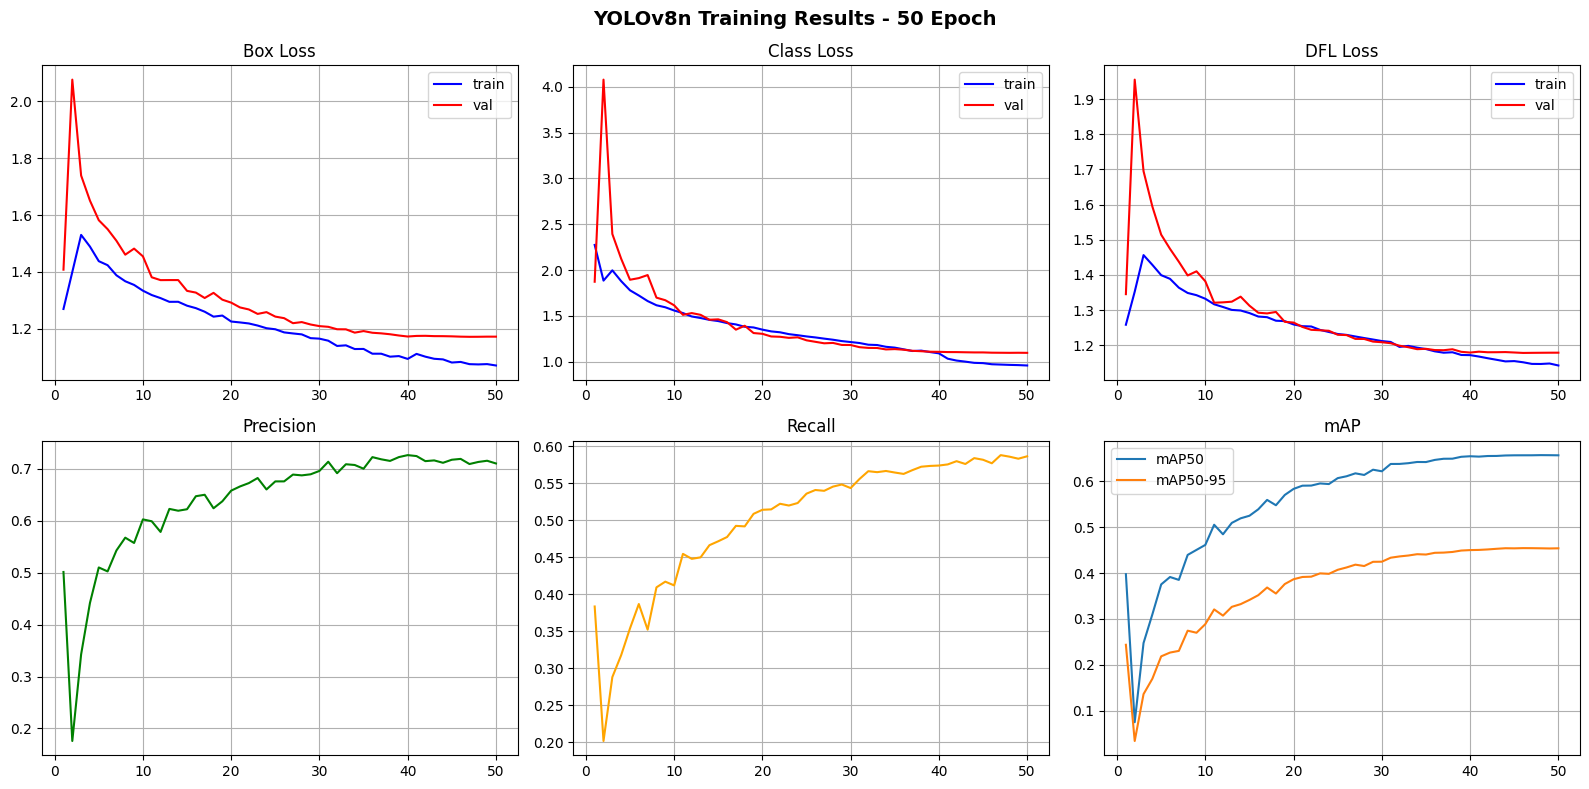

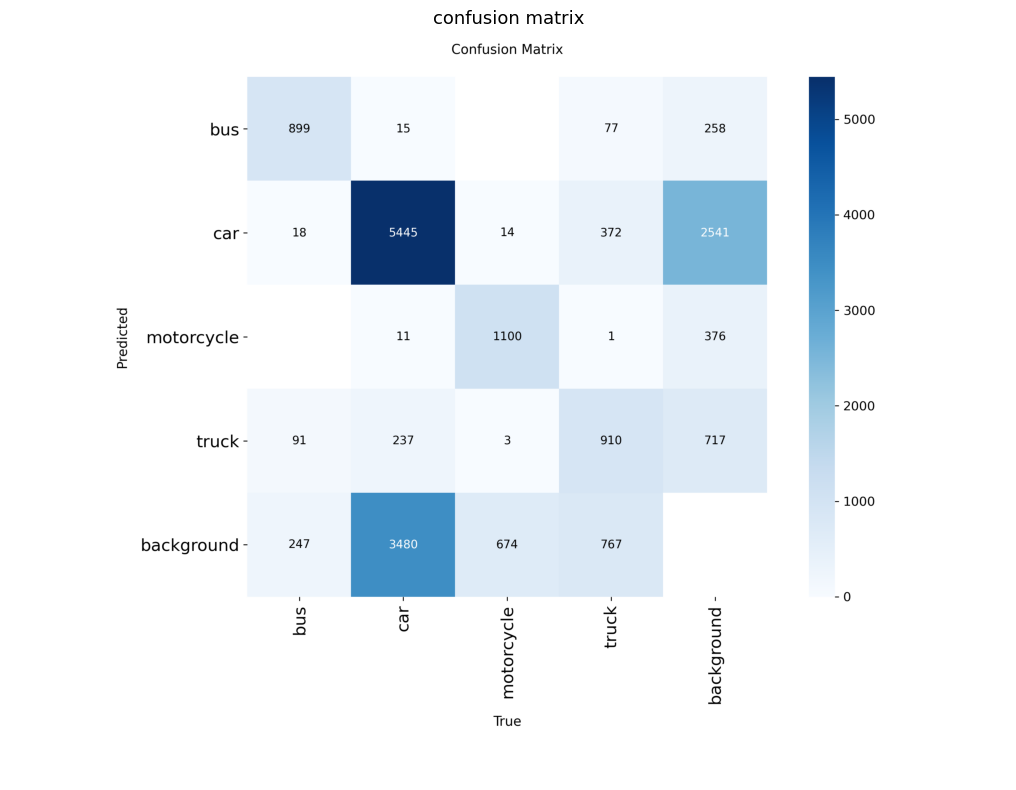

✅ confusion_matrix.png


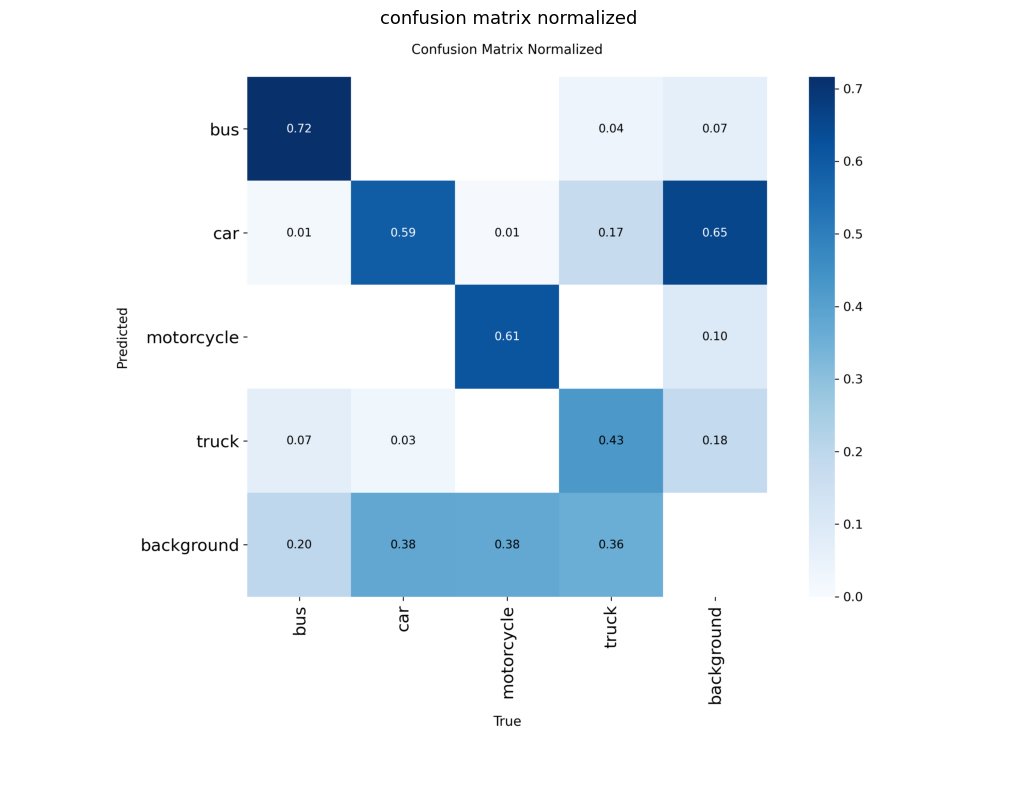

✅ confusion_matrix_normalized.png


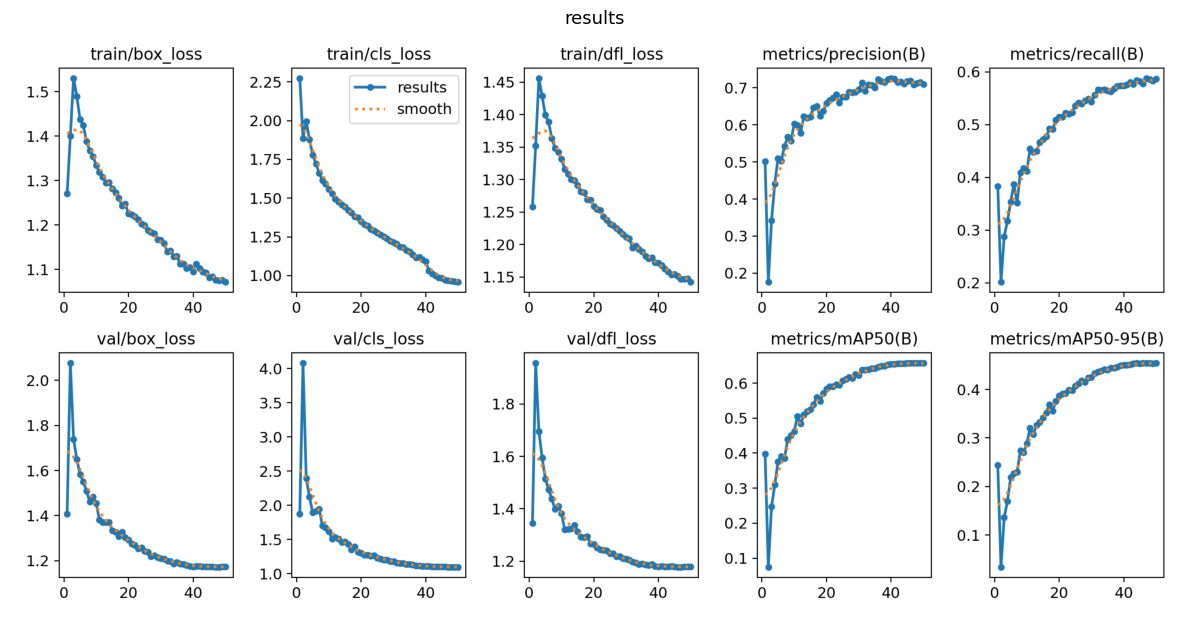

✅ results.png


In [3]:
# ============================================
# LIHAT GRAFIK HASIL TRAINING
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import drive
import os

drive.mount('/content/drive')
TRAIN_DIR = '/content/drive/MyDrive/yolo_training/yolov8n'

# ============================================
# 1. GRAFIK LOSS & METRIK DARI results.csv
# ============================================
csv_path = f'{TRAIN_DIR}/results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('YOLOv8n Training Results - 50 Epoch', fontsize=14, fontweight='bold')

axes[0,0].plot(df['epoch'], df['train/box_loss'], 'b-', label='train')
axes[0,0].plot(df['epoch'], df['val/box_loss'],   'r-', label='val')
axes[0,0].set_title('Box Loss'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(df['epoch'], df['train/cls_loss'], 'b-', label='train')
axes[0,1].plot(df['epoch'], df['val/cls_loss'],   'r-', label='val')
axes[0,1].set_title('Class Loss'); axes[0,1].legend(); axes[0,1].grid(True)

axes[0,2].plot(df['epoch'], df['train/dfl_loss'], 'b-', label='train')
axes[0,2].plot(df['epoch'], df['val/dfl_loss'],   'r-', label='val')
axes[0,2].set_title('DFL Loss'); axes[0,2].legend(); axes[0,2].grid(True)

axes[1,0].plot(df['epoch'], df['metrics/precision(B)'], 'g-')
axes[1,0].set_title('Precision'); axes[1,0].grid(True)

axes[1,1].plot(df['epoch'], df['metrics/recall(B)'], color='orange')
axes[1,1].set_title('Recall'); axes[1,1].grid(True)

axes[1,2].plot(df['epoch'], df['metrics/mAP50(B)'],    label='mAP50')
axes[1,2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
axes[1,2].set_title('mAP'); axes[1,2].legend(); axes[1,2].grid(True)

plt.tight_layout()
plt.show()

# ============================================
# 2. CONFUSION MATRIX & KURVA BAWAAN YOLO
# ============================================
for img_name in ['confusion_matrix.png', 'confusion_matrix_normalized.png',
                 'PR_curve.png', 'F1_curve.png', 'results.png']:
    img_path = f'{TRAIN_DIR}/{img_name}'
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_name.replace('.png','').replace('_',' '), fontsize=13)
        plt.tight_layout()
        plt.show()
        print(f"✅ {img_name}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

0: 640x640 (no detections), 53.4ms
1: 640x640 1 bus, 3 cars, 53.4ms
2: 640x640 4 cars, 1 truck, 53.4ms
3: 640x640 2 cars, 1 truck, 53.4ms
4: 640x640 1 car, 1 truck, 53.4ms
5: 640x640 3 cars, 1 motorcycle, 53.4ms
Speed: 4.7ms preprocess, 53.4ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/test_predict


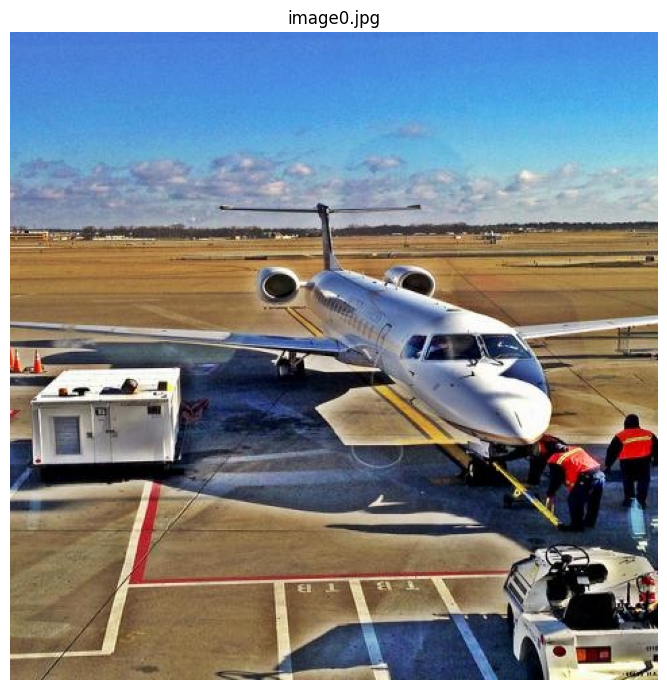

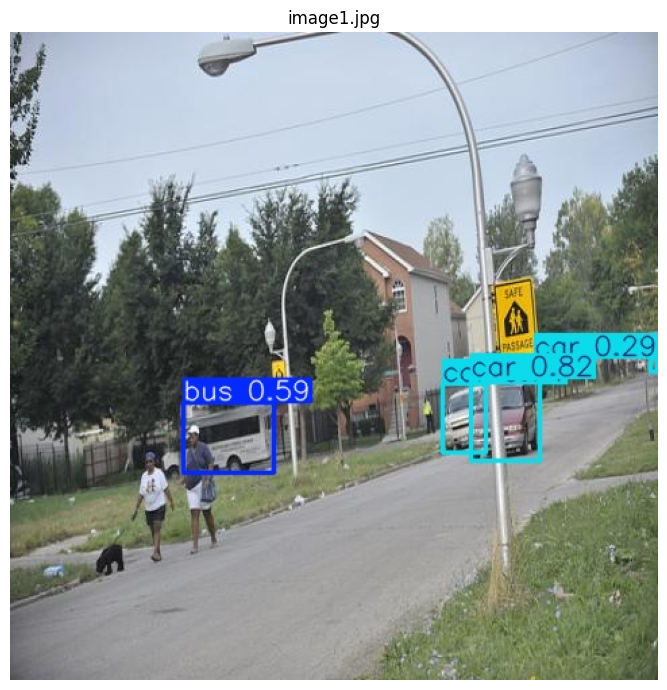

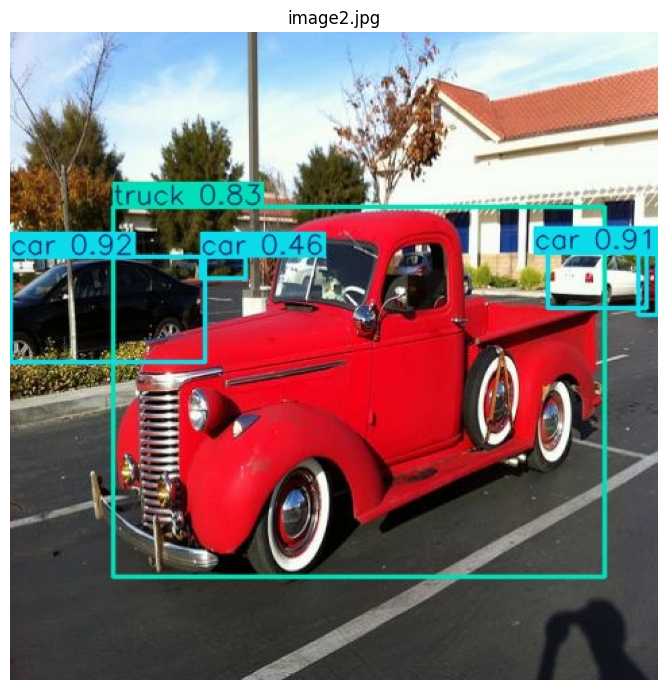

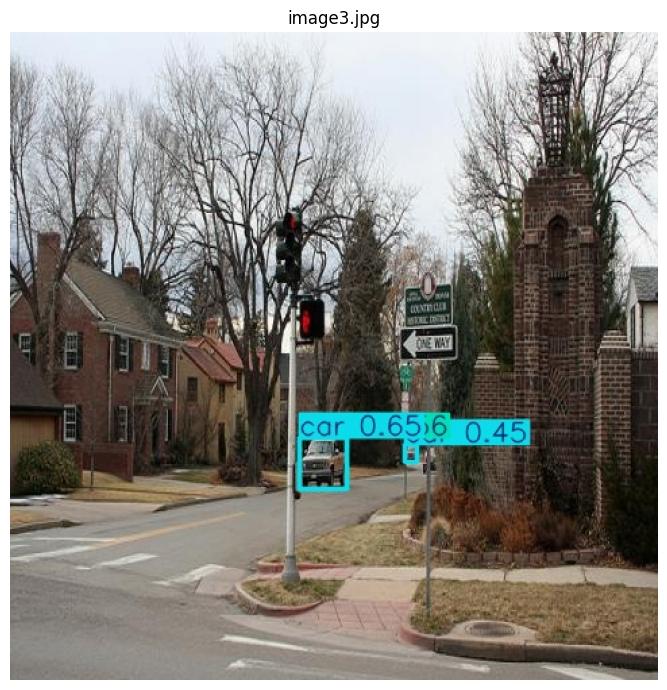

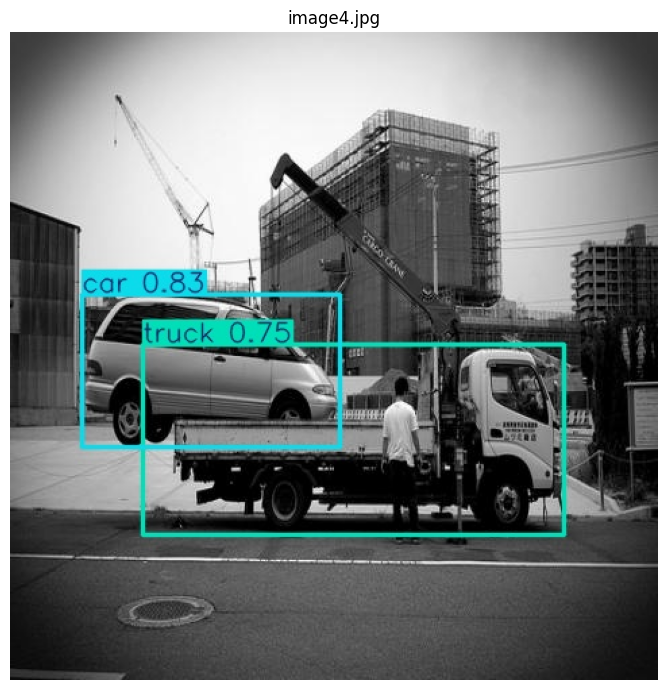

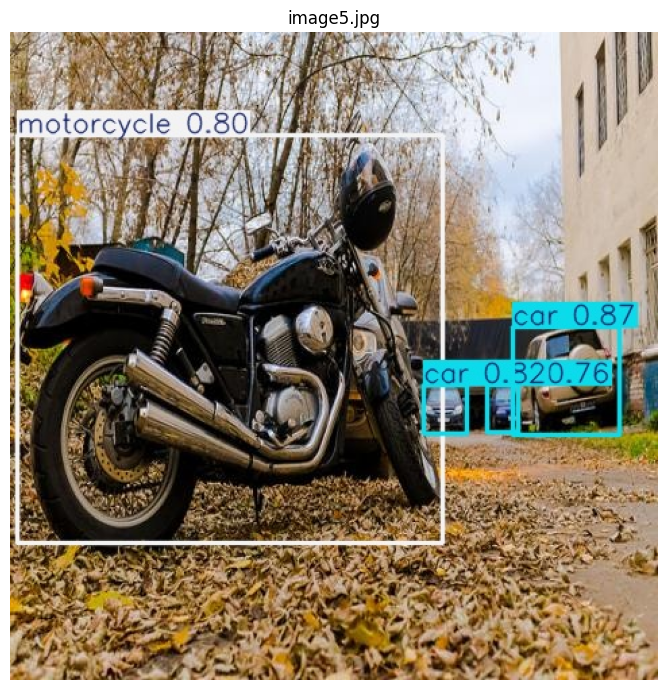

✅ Tes selesai!


In [4]:
from ultralytics import YOLO
from google.colab import drive
import glob, random, os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

drive.mount('/content/drive')
model = YOLO('/content/drive/MyDrive/yolo_training/yolov8n/weights/best.pt')

# Ambil 6 gambar random dari val set
images = glob.glob('/content/dataset/valid/images/*.jpg')
sample  = random.sample(images, min(6, len(images)))

# Prediksi
results = model.predict(
    source  = sample,
    device  = 0,
    conf    = 0.25,
    save    = True,
    project = '/content',
    name    = 'test_predict',
    exist_ok= True,
)

# Tampilkan hasil
pred_dir = '/content/test_predict'
for img_file in sorted(os.listdir(pred_dir))[:6]:
    img = mpimg.imread(f'{pred_dir}/{img_file}')
    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_file)
    plt.tight_layout()
    plt.show()

print("✅ Tes selesai!")

In [5]:
from google.colab import files, drive
import shutil

drive.mount('/content/drive')

# Copy best.pt → yolov8n.pt lalu download
src = '/content/drive/MyDrive/yolo_training/yolov8n/weights/best.pt'
dst = '/content/yolov8n.pt'

shutil.copy(src, dst)
print("✅ Siap download...")
files.download(dst)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Siap download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

model = YOLO('/content/drive/MyDrive/yolo_training/yolov8n/weights/best.pt')

metrics = model.val(
    data    = "/content/dataset/data.yaml",
    device  = 0,
    conf    = 0.25,
    iou     = 0.6,
    verbose = True,
)

print("\n📊 Hasil Evaluasi:")
print(f"   mAP50        : {metrics.box.map50:.4f}")
print(f"   mAP50-95     : {metrics.box.map:.4f}")
print(f"   Precision    : {metrics.box.mp:.4f}")
print(f"   Recall       : {metrics.box.mr:.4f}")

print("\n📊 Per Kelas:")
names = ['bus', 'car', 'motorcycle', 'truck']
for i, name in enumerate(names):
    print(f"   {name:12s} → mAP50: {metrics.box.ap50[i]:.4f}  |  AP50-95: {metrics.box.ap[i]:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 25.5±5.7 MB/s, size: 43.8 KB)
val: Scanning /content/dataset/valid/labels.cache... 3798 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3798/3798 885.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 238/238 6.2it/s 38.6s
                   all       3798      14361      0.692      0.608      0.686      0.516
                   bus        817       1255       0.76      0.738      0.809      0.689
                   car       2566       9188        0.7      0.603       0.68      0.481
            motorcycle        729       1791      0.759      0.595       0.71      0.477
      